In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TeachingRatings.csv to TeachingRatings.csv


In [ ]:
df = pd.read_csv("TeachingRatings.csv")

In [ ]:
df.head()

,rownames,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,1,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,2,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,3,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,4,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,5,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5


In [ ]:
df.shape

(463, 13)

#  Can you identify whether teachers Rating Data is a time serires or cross sectional?
This dataset is cross-sectional data. It contains observations for different instructors and courses, with variables such as gender, beauty, evaluation, students and tenure. The observations represent different units rather than repeated measurements taken at regular time intervals.

In [ ]:
print("Mean:", df["students"].mean())
print("Median:", df["students"].median())
print("Minimum:", df["students"].min())
print("Maximum:", df["students"].max())

Mean: 36.62419006479482
Median: 23.0
Minimum: 5
Maximum: 380


In [ ]:
df.columns

Index(['rownames', 'minority', 'age', 'gender', 'credits', 'beauty', 'eval',
       'division', 'native', 'tenure', 'students', 'allstudents', 'prof'],
      dtype='object')

In [ ]:
df.describe().round(2)

,rownames,age,beauty,eval,students,allstudents,prof
count,463.0,463.00,463.00,463.00,463.00,463.00,463.00
mean,232.0,48.37,0.00,4.00,36.62,55.18,45.43
std,133.8,9.80,0.79,0.55,45.02,75.07,27.51
min,1.0,29.00,-1.45,2.10,5.00,8.00,1.00
25%,116.5,42.00,-0.66,3.60,15.00,19.00,20.00
50%,232.0,48.00,-0.07,4.00,23.00,29.00,44.00
75%,347.5,57.00,0.55,4.40,40.00,60.00,70.50
max,463.0,73.00,1.97,5.00,380.00,581.00,94.00


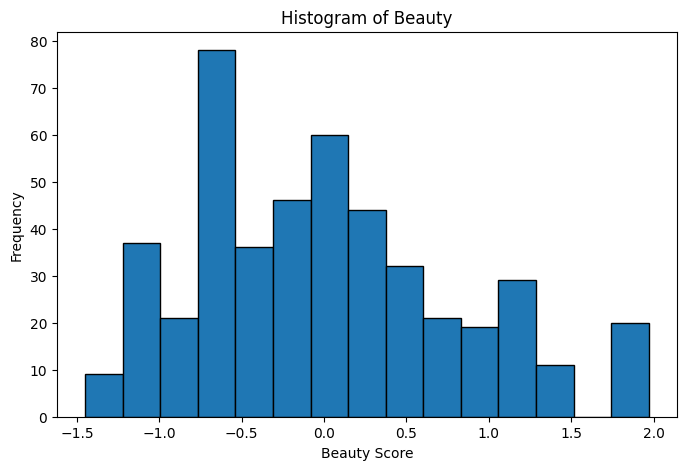

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["beauty"], bins=15, edgecolor="black")
plt.xlabel("Beauty Score")
plt.ylabel("Frequency")
plt.title("Histogram of Beauty")
plt.show()

The histogram shows the distribution of the beauty scores of the professors. The scores range approximately from -1.45 to 1.97, with most observations concentrated between -1 and 0.5. The distribution is not perfectly symmetric and shows some variation in the frequency of observations across the range. There are relatively fewer observations at the extreme values. Overall, the beauty scores show a moderately irregular distribution rather than a perfectly normal distribution.

In [ ]:
gender_beauty  = df.groupby("gender")["beauty"].agg(["mean", "std"])
gender_beauty.round(2)

,mean,std
gender,,
female,0.12,0.82
male,-0.08,0.76


The average beauty score differs between male and female instructors. Female instructors have a mean beauty score of 0.12 with a standard deviation of 0.82, whereas male instructors have a mean beauty score of -0.08 with a standard deviation of 0.76. Thus, female instructors have a higher average beauty score than male instructors in this sample. The standard deviations are relatively similar, indicating comparable variability in beauty scores for both groups.

In [ ]:
df["tenure"].value_counts()

,count
tenure,
yes,361
no,102


In [ ]:
df.groupby("gender")["tenure"].value_counts()

gender  tenure
female  yes       145
        no         50
male    yes       216
        no         52
Name: count, dtype: int64

In [ ]:
tenure_percentage = (
    df.groupby("gender")["tenure"]
    .apply(lambda x: (x == "yes").mean() * 100)
)
tenure_percentage.round(2)


,tenure
gender,
female,74.36
male,80.60


The percentage of female instructors who are tenured is 74.36%, while the percentage of male instructors who are tenured is 80.60%. Therefore, the proportion of instructors with tenure differs by gender in this sample, with male instructors having a higher percentage of tenured instructors than female instructors.